In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from config import BENCHMARKS
from utils import plot_pool_distribution
from sensitivity_analysis.sensitivity_utils import load_scores, sweep_thresholds, plot_sweep

BENCHMARK = "RANDOM"
BENCH_PARAMS = BENCHMARKS[BENCHMARK]
METRIC_COL = BENCH_PARAMS["metric_col"]
THRESHOLD = BENCH_PARAMS["threshold"]
METRIC_OP = BENCH_PARAMS["metric_op"]
SAMPLE_SIZE = BENCH_PARAMS["sample_size"]
SPARSITY_MIN = BENCH_PARAMS["sparsity_min"]
XLABEL = f"Max |ACF| (lags 1–{int(BENCH_PARAMS['max_lag_factor'])})"

SOURCES = [
    ("institutions", "Institutions"),
    ("subnets", "Subnets"),
    ("ips_full", "IPs"),
]

SWEEP_RANGE = np.arange(0.05, 0.31, 0.0025)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

GRAPH_DIR = Path('sensitivity_analysis/figures')
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print(f"Benchmark: {BENCHMARK}")
print(f"Threshold: {METRIC_COL} {METRIC_OP} {THRESHOLD}")
print(f"Sparsity filter: ratio_active >= {SPARSITY_MIN}")
print(f"Sample size: {SAMPLE_SIZE}")

Benchmark: RANDOM
Threshold: max_acf <= 0.1
Sparsity filter: ratio_active >= 0.4
Sample size: 25


## Hourly

In [2]:
print("Loading hourly scores:")
scores_hourly_raw = load_scores("hourly", BENCHMARK, SOURCES)

scores_hourly = {}
for label, df in scores_hourly_raw.items():
    filtered = df[df["ratio_active"] >= SPARSITY_MIN].copy()
    print(f"  {label}: {len(filtered)}/{len(df)} pass sparsity >= {SPARSITY_MIN}")
    scores_hourly[label] = filtered

Loading hourly scores:
  Institutions: 283 series
  Subnets: 548 series
  IPs: 275124 series
  Institutions: 281/283 pass sparsity >= 0.4
  Subnets: 535/548 pass sparsity >= 0.4
  IPs: 42706/275124 pass sparsity >= 0.4


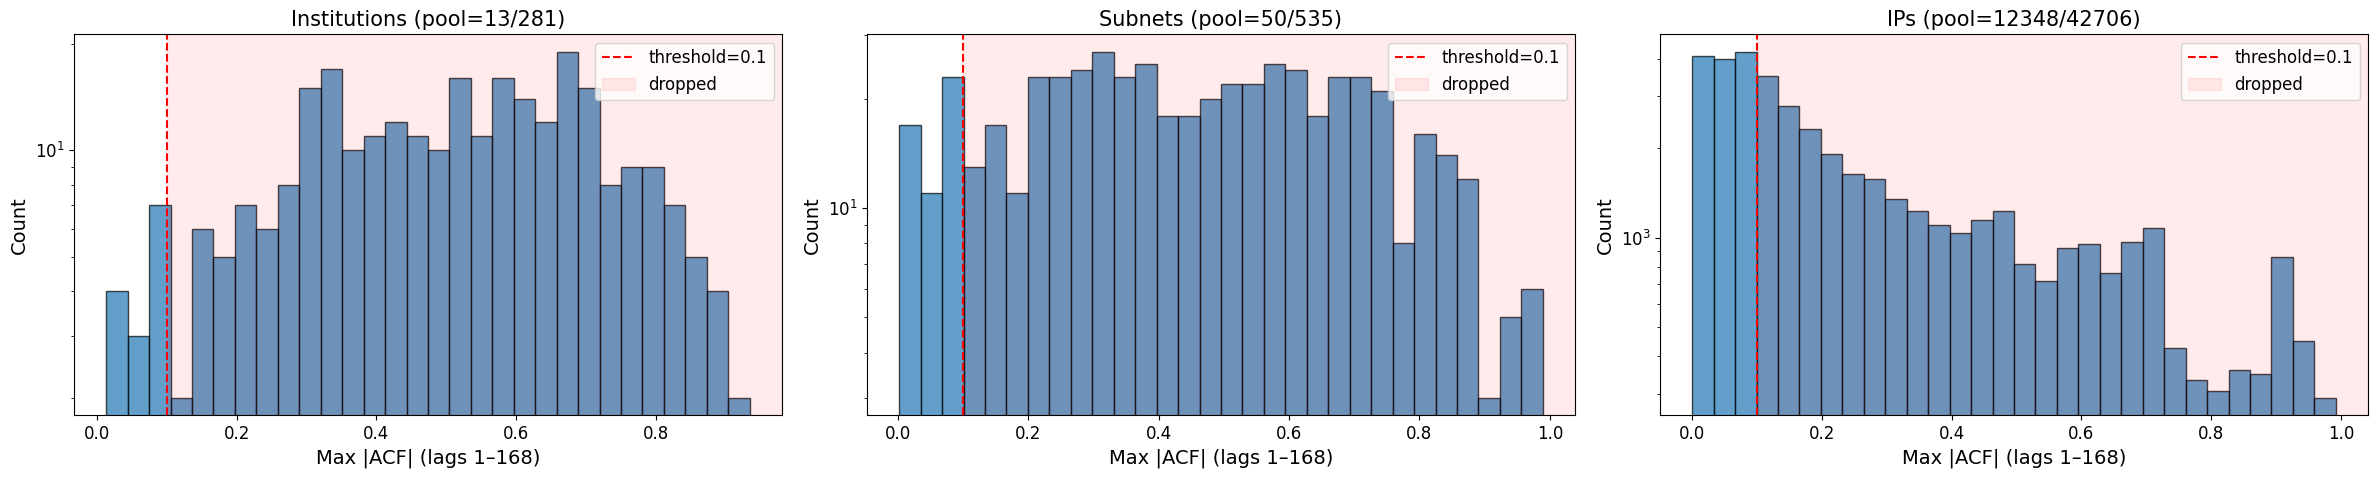

In [3]:
plot_pool_distribution(
    [(scores_hourly[label], label) for _, label in SOURCES],
    metric_col=METRIC_COL,
    threshold=THRESHOLD,
    metric_op=METRIC_OP,
    xlabel=XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / f"{BENCHMARK}_pool_distribution_hourly.pdf",
)

In [4]:
sweep_hourly = sweep_thresholds(scores_hourly, METRIC_COL, SWEEP_RANGE, metric_op=METRIC_OP)
display(sweep_hourly)

,threshold,Institutions pool,Institutions median,Subnets pool,Subnets median,IPs pool,IPs median
0,0.05,5,0.018,25,0.029,5889,0.022
1,0.05,5,0.018,25,0.029,6200,0.023
2,0.06,6,0.028,26,0.031,6534,0.025
3,0.06,6,0.028,26,0.031,6872,0.027
4,0.06,6,0.028,26,0.031,7228,0.029
...,...,...,...,...,...,...,...
99,0.30,50,0.194,162,0.167,25998,0.106
100,0.30,50,0.194,162,0.167,26125,0.106
101,0.30,53,0.195,166,0.177,26233,0.107
102,0.31,54,0.196,168,0.183,26330,0.107


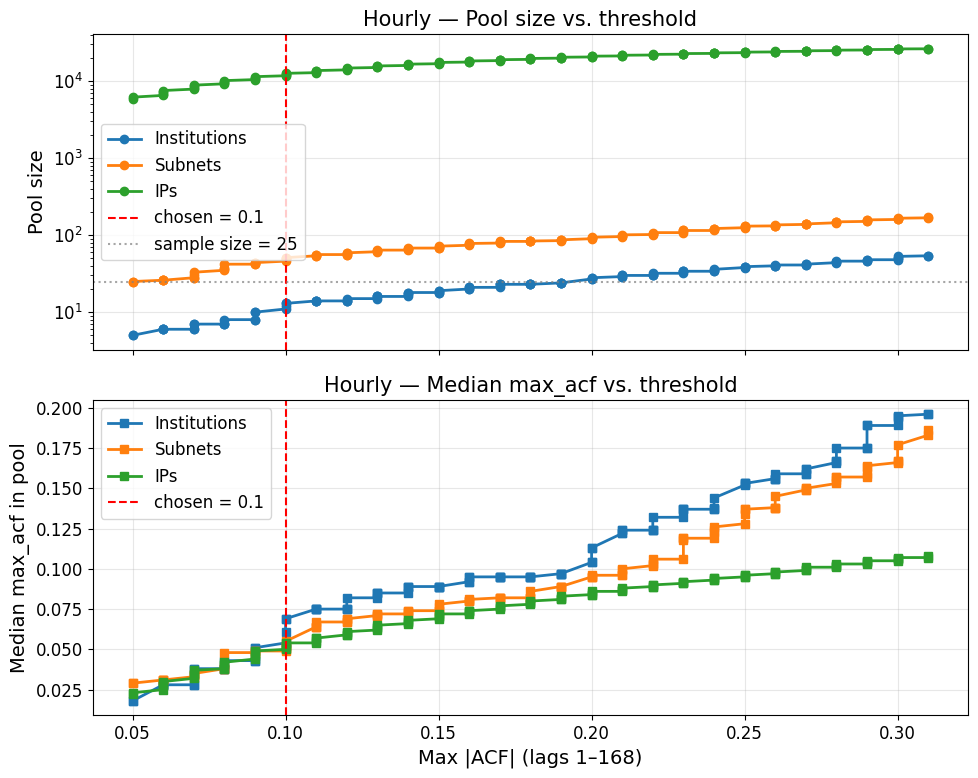

In [5]:
plot_sweep(sweep_hourly, "Hourly", THRESHOLD, SAMPLE_SIZE, XLABEL, METRIC_COL,
           save_path=GRAPH_DIR / f"{BENCHMARK}_sweep_hourly.pdf", log_y=True)

## 10-Minute

In [6]:
print("Loading 10-minute scores:")
scores_10min_raw = load_scores("10min", BENCHMARK, SOURCES)

scores_10min = {}
for label, df in scores_10min_raw.items():
    filtered = df[df["ratio_active"] >= SPARSITY_MIN].copy()
    print(f"  {label}: {len(filtered)}/{len(df)} pass sparsity >= {SPARSITY_MIN}")
    scores_10min[label] = filtered

Loading 10-minute scores:
  Institutions: 283 series
  Subnets: 548 series
  IPs: 275124 series
  Institutions: 266/283 pass sparsity >= 0.4
  Subnets: 468/548 pass sparsity >= 0.4
  IPs: 34729/275124 pass sparsity >= 0.4


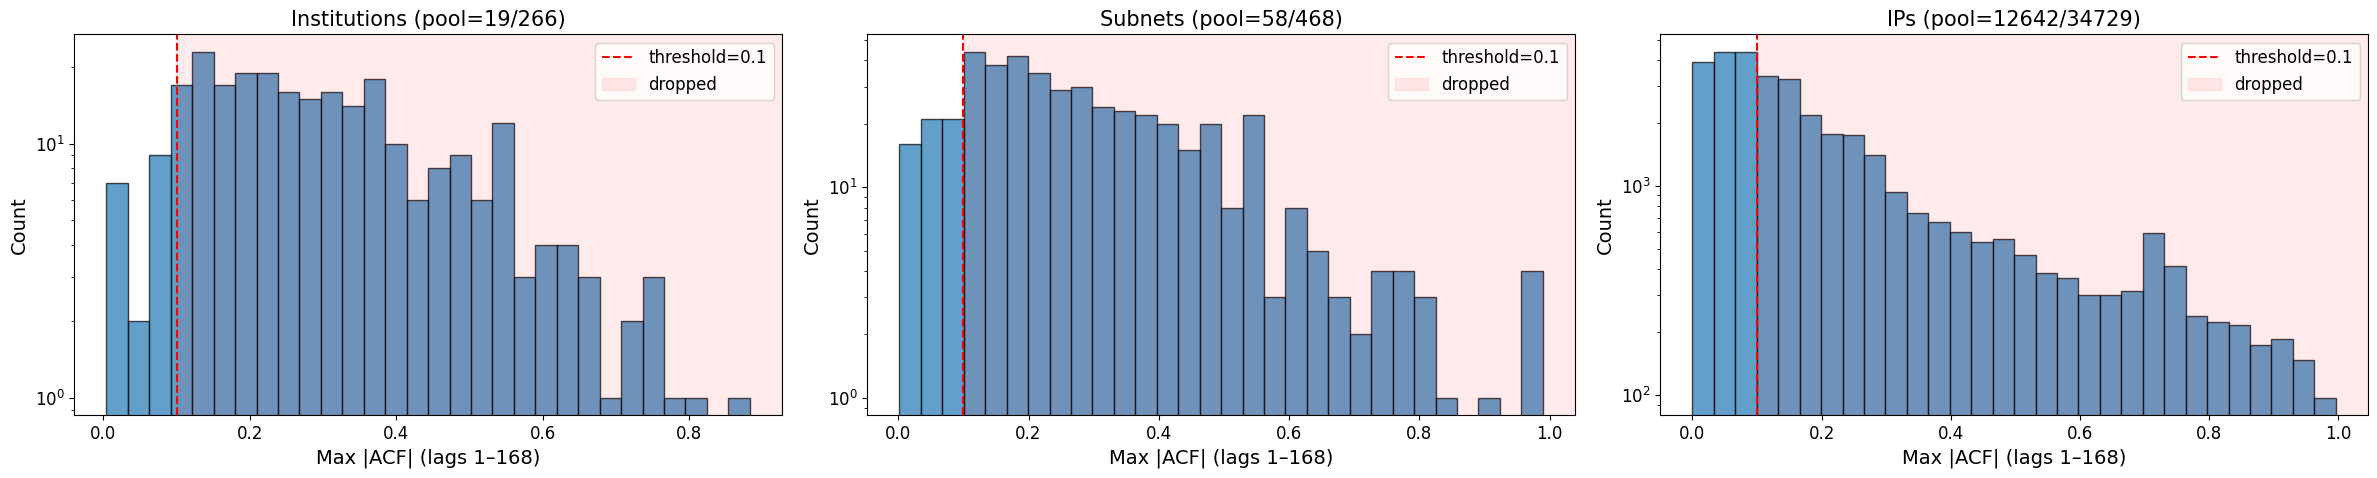

In [7]:
plot_pool_distribution(
    [(scores_10min[label], label) for _, label in SOURCES],
    metric_col=METRIC_COL,
    threshold=THRESHOLD,
    metric_op=METRIC_OP,
    xlabel=XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / f"{BENCHMARK}_pool_distribution_10min.pdf",
)

In [8]:
sweep_10min = sweep_thresholds(scores_10min, METRIC_COL, SWEEP_RANGE, metric_op=METRIC_OP)
display(sweep_10min)

,threshold,Institutions pool,Institutions median,Subnets pool,Subnets median,IPs pool,IPs median
0,0.05,8,0.028,23,0.023,5979,0.025
1,0.05,8,0.028,25,0.025,6281,0.026
2,0.06,8,0.028,26,0.026,6629,0.028
3,0.06,9,0.029,28,0.028,6953,0.029
4,0.06,9,0.029,30,0.031,7318,0.031
...,...,...,...,...,...,...,...
99,0.30,144,0.176,274,0.159,26223,0.104
100,0.30,149,0.180,280,0.166,26322,0.105
101,0.30,150,0.180,281,0.168,26416,0.105
102,0.31,151,0.180,283,0.169,26493,0.105


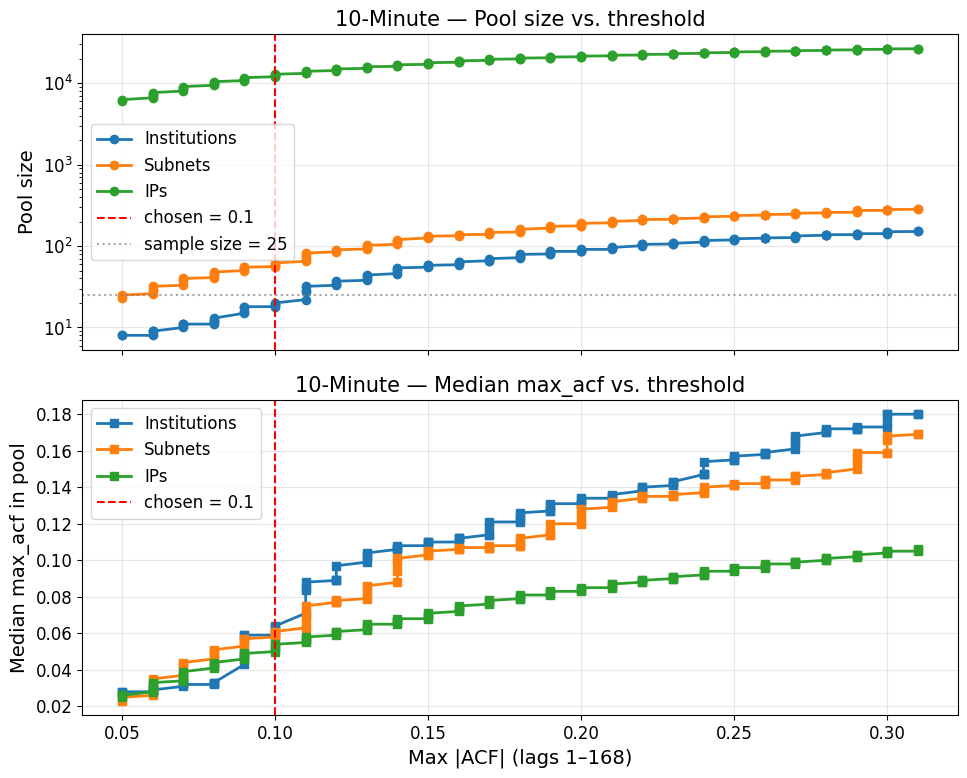

In [9]:
plot_sweep(sweep_10min, "10-Minute", THRESHOLD, SAMPLE_SIZE, XLABEL, METRIC_COL,
           save_path=GRAPH_DIR / f"{BENCHMARK}_sweep_10min.pdf", log_y=True)